# Introduction

In today’s fast-paced food delivery industry, predicting delivery time is critical for improving customer satisfaction and optimizing logistics.
This project focuses on building a machine learning pipeline to estimate the delivery time of food orders based on multiple factors such as:

-  Location features (restaurant & delivery coordinates, distance)- 
-  Weather conditions- 
-  Traffic level- 
-  Type of vehicle & order- 
-  Time-based factors (rush hours, weekends, order shift, etc.)

Ultimate goal is to develop a robust ML model, deploy it with an interactive dashboard, and provide actionable insights.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/food-delivery-dataset/Sample_Submission.csv
/kaggle/input/food-delivery-dataset/train.csv
/kaggle/input/food-delivery-dataset/test.csv


In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")
import math
from geopy.distance import geodesic
import folium
from folium.plugins import MarkerCluster
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [3]:
train_df = pd.read_csv('/kaggle/input/food-delivery-dataset/train.csv')
train_df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [4]:
train_df.shape

(45593, 20)

In [5]:
print("\nTrain head:")
display(train_df.head())



Train head:


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [6]:
print("\nTrain info:")
print(train_df.info())



Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Veh

In [7]:
print("\n train describe")
display(train_df.describe())




 train describe


,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702,1.023359
std,8.185109,22.883647,7.335122,21.118812,0.839065
min,-30.905562,-88.366217,0.010000,0.010000,0.000000
25%,12.933284,73.170000,12.988453,73.280000,0.000000
50%,18.546947,75.898497,18.633934,76.002574,1.000000
75%,22.728163,78.044095,22.785049,78.107044,2.000000
max,30.914057,88.433452,31.054057,88.563452,3.000000


In [8]:
#checking the missing values
def missing_summary(df, name):
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    if not miss.empty:
        print(f"\n{name} missing values:")
        print(miss)
    else:
        print(f"\n{name} has no missing values.")

missing_summary(train_df, "Train")



Train has no missing values.


## This is a false metric we are getting because some of the columns have string values instead of numerical values. So there are indeed missing values we will have to handle them before training the model later.

In [9]:
# Unique values

print("\nUnique values per column (TRAIN):")
print("*" * 50)
for col in train_df.columns:
    unique_vals = train_df[col].unique()
    n_unique = train_df[col].nunique()
    
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {n_unique}")
    
    if n_unique <= 10:  
        print("Values:", list(unique_vals))
    else:
        print("list of values:", list(unique_vals[:10]))
    print("*" * 50)




Unique values per column (TRAIN):
**************************************************

Column: ID
Number of unique values: 45593
list of values: ['0x4607 ', '0xb379 ', '0x5d6d ', '0x7a6a ', '0x70a2 ', '0x9bb4 ', '0x95b4 ', '0x9eb2 ', '0x1102 ', '0xcdcd ']
**************************************************

Column: Delivery_person_ID
Number of unique values: 1320
list of values: ['INDORES13DEL02 ', 'BANGRES18DEL02 ', 'BANGRES19DEL01 ', 'COIMBRES13DEL02 ', 'CHENRES12DEL01 ', 'HYDRES09DEL03 ', 'RANCHIRES15DEL01 ', 'MYSRES15DEL02 ', 'HYDRES05DEL02 ', 'DEHRES17DEL01 ']
**************************************************

Column: Delivery_person_Age
Number of unique values: 23
list of values: ['37', '34', '23', '38', '32', '22', '33', '35', '36', '21']
**************************************************

Column: Delivery_person_Ratings
Number of unique values: 29
list of values: ['4.9', '4.5', '4.4', '4.7', '4.6', '4.8', '4.2', '4.3', '4', '4.1']
***********************************************

In [10]:
#target col
if "Time_taken(min)" in train_df.columns:
    print("\nTarget column stats:")
    print(train_df["Time_taken(min)"].describe())
    print("\nSample values:", train_df["Time_taken(min)"].unique()[:10])



Target column stats:
count        45593
unique          45
top       (min) 26
freq          2123
Name: Time_taken(min), dtype: object

Sample values: ['(min) 24' '(min) 33' '(min) 26' '(min) 21' '(min) 30' '(min) 40'
 '(min) 32' '(min) 34' '(min) 46' '(min) 23']


In [11]:
train_df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

# Cleaning the data

In [12]:
#cleaning the columns
def basic_clean(df):
    df = df.copy()
    # standardizing column names
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    
    # parsing date/time columns if present
    if "order_date" in df.columns:
        df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce", dayfirst=True)
    for tcol in ["time_orderd", "time_order_picked"]:
        if tcol in df.columns:
            df[tcol] = pd.to_datetime(df[tcol], errors="coerce").dt.round("s")
    
    # clean and convert numeric columns
    df = df.rename(columns={"time_taken(min)": "time_taken_min"})
    if "time_taken_min" in df.columns:
        df["time_taken_min"] = (
            df["time_taken_min"]
            .astype(str)
            .str.extract(r"(\d+)")
            .astype(float)
        )
    
    for col in ["delivery_person_age", "delivery_person_ratings", "vehicle_condition", "multiple_deliveries"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    
    # trimming string columns
    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].astype(str).str.strip()
    
    return df



train_df = basic_clean(train_df)



In [13]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id                           45593 non-null  object        
 1   delivery_person_id           45593 non-null  object        
 2   delivery_person_age          43739 non-null  float64       
 3   delivery_person_ratings      43685 non-null  float64       
 4   restaurant_latitude          45593 non-null  float64       
 5   restaurant_longitude         45593 non-null  float64       
 6   delivery_location_latitude   45593 non-null  float64       
 7   delivery_location_longitude  45593 non-null  float64       
 8   order_date                   45593 non-null  datetime64[ns]
 9   time_orderd                  43862 non-null  datetime64[ns]
 10  time_order_picked            45593 non-null  datetime64[ns]
 11  weatherconditions            45593 non-nu

In [14]:
train_df

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,time_order_picked,weatherconditions,road_traffic_density,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken_min
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2025-11-20 11:30:00,2025-11-20 11:45:00,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2025-11-20 19:45:00,2025-11-20 19:50:00,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2025-11-20 08:30:00,2025-11-20 08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2025-11-20 18:00:00,2025-11-20 18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2025-11-20 13:30:00,2025-11-20 13:45:00,conditions Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,2025-11-20 11:35:00,2025-11-20 11:45:00,conditions Windy,High,1,Meal,motorcycle,0.0,No,Metropolitian,32.0
45589,0xd641,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,2025-11-20 19:55:00,2025-11-20 20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,36.0
45590,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,2025-11-20 23:50:00,2025-11-20 00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0.0,No,Metropolitian,16.0
45591,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,2025-11-20 13:35:00,2025-11-20 13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1.0,No,Metropolitian,26.0


In [15]:
(train_df.isna().sum() / len(train_df)) * 100


id                             0.000000
delivery_person_id             0.000000
delivery_person_age            4.066414
delivery_person_ratings        4.184853
restaurant_latitude            0.000000
restaurant_longitude           0.000000
delivery_location_latitude     0.000000
delivery_location_longitude    0.000000
order_date                     0.000000
time_orderd                    3.796635
time_order_picked              0.000000
weatherconditions              0.000000
road_traffic_density           0.000000
vehicle_condition              0.000000
type_of_order                  0.000000
type_of_vehicle                0.000000
multiple_deliveries            2.177966
festival                       0.000000
city                           0.000000
time_taken_min                 0.000000
dtype: float64

In [16]:
print("Missing values in Train set:")
print(train_df.isna().sum()[train_df.isna().sum() > 0])




Missing values in Train set:
delivery_person_age        1854
delivery_person_ratings    1908
time_orderd                1731
multiple_deliveries         993
dtype: int64


In [17]:
train_df

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,time_order_picked,weatherconditions,road_traffic_density,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken_min
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2025-11-20 11:30:00,2025-11-20 11:45:00,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2025-11-20 19:45:00,2025-11-20 19:50:00,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2025-11-20 08:30:00,2025-11-20 08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2025-11-20 18:00:00,2025-11-20 18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2025-11-20 13:30:00,2025-11-20 13:45:00,conditions Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,2025-11-20 11:35:00,2025-11-20 11:45:00,conditions Windy,High,1,Meal,motorcycle,0.0,No,Metropolitian,32.0
45589,0xd641,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,2025-11-20 19:55:00,2025-11-20 20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,36.0
45590,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,2025-11-20 23:50:00,2025-11-20 00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0.0,No,Metropolitian,16.0
45591,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,2025-11-20 13:35:00,2025-11-20 13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1.0,No,Metropolitian,26.0


# Feature Engineering 

In [18]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id                           45593 non-null  object        
 1   delivery_person_id           45593 non-null  object        
 2   delivery_person_age          43739 non-null  float64       
 3   delivery_person_ratings      43685 non-null  float64       
 4   restaurant_latitude          45593 non-null  float64       
 5   restaurant_longitude         45593 non-null  float64       
 6   delivery_location_latitude   45593 non-null  float64       
 7   delivery_location_longitude  45593 non-null  float64       
 8   order_date                   45593 non-null  datetime64[ns]
 9   time_orderd                  43862 non-null  datetime64[ns]
 10  time_order_picked            45593 non-null  datetime64[ns]
 11  weatherconditions            45593 non-nu

In [19]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

In [20]:
train_df.head()

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,time_order_picked,weatherconditions,road_traffic_density,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken_min
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2025-11-20 11:30:00,2025-11-20 11:45:00,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2025-11-20 19:45:00,2025-11-20 19:50:00,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2025-11-20 08:30:00,2025-11-20 08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2025-11-20 18:00:00,2025-11-20 18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2025-11-20 13:30:00,2025-11-20 13:45:00,conditions Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0


In [21]:
# order/pick hours
train_df["order_hour"] = pd.to_datetime(train_df["time_orderd"], errors="coerce").dt.hour
train_df["pickup_hour"] = pd.to_datetime(train_df["time_order_picked"], errors="coerce").dt.hour


In [22]:
# delivery_duration (minutes)
train_df["delivery_duration_min"] = (pd.to_datetime(train_df["time_order_picked"]) - pd.to_datetime(train_df["time_orderd"])).dt.total_seconds()/60
train_df["delivery_duration_min"]

0          15.0
1           5.0
2          15.0
3          10.0
4          15.0
          ...  
45588      10.0
45589      15.0
45590   -1425.0
45591       5.0
45592       5.0
Name: delivery_duration_min, Length: 45593, dtype: float64

## There are some negative time for delivery duration

In [23]:
train_df.loc[train_df["delivery_duration_min"] < 0, ["time_orderd", "time_order_picked"]]


,time_orderd,time_order_picked
75,2025-11-20 23:50:00,2025-11-20 00:05:00
101,2025-11-20 23:55:00,2025-11-20 00:10:00
164,2025-11-20 23:50:00,2025-11-20 00:00:00
166,2025-11-20 23:45:00,2025-11-20 00:00:00
325,2025-11-20 23:55:00,2025-11-20 00:10:00
...,...,...
45246,2025-11-20 23:50:00,2025-11-20 00:00:00
45361,2025-11-20 23:50:00,2025-11-20 00:05:00
45529,2025-11-20 23:50:00,2025-11-20 00:05:00
45535,2025-11-20 23:50:00,2025-11-20 00:00:00


In [24]:
def fix_delivery_duration(df, order_col="time_orderd", pick_col="time_order_picked"):
    # Ensure datetime
    train_df[order_col] = pd.to_datetime(train_df[order_col])
    train_df[pick_col] = pd.to_datetime(train_df[pick_col])
    
    # If pick-up is earlier than order (spans midnight), adding 1 day
    train_df.loc[train_df[pick_col] < train_df[order_col], pick_col] += pd.Timedelta(days=1)
    
    # Calculate duration in minutes
    train_df["delivery_duration_min"] = (train_df[pick_col] - train_df[order_col]).dt.total_seconds() / 60
    return df

# Apply to train and test sets
train_df = fix_delivery_duration(train_df)


In [25]:
#Rechecking again 
# delivery_duration (minutes)
train_df["delivery_duration_min"] = (pd.to_datetime(train_df["time_order_picked"]) - pd.to_datetime(train_df["time_orderd"])).dt.total_seconds()/60
train_df["delivery_duration_min"]



0        15.0
1         5.0
2        15.0
3        10.0
4        15.0
         ... 
45588    10.0
45589    15.0
45590    15.0
45591     5.0
45592     5.0
Name: delivery_duration_min, Length: 45593, dtype: float64

In [26]:
# day/month/week
train_df["day_of_week"] = train_df["order_date"].dt.day_name()
train_df["is_weekend"] = train_df["order_date"].dt.dayofweek >= 5
train_df["month"] = train_df["order_date"].dt.month

In [27]:
train_df.head()

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,...,multiple_deliveries,festival,city,time_taken_min,order_hour,pickup_hour,delivery_duration_min,day_of_week,is_weekend,month
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2025-11-20 11:30:00,...,0.0,No,Urban,24.0,11.0,11,15.0,Saturday,True,3
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2025-11-20 19:45:00,...,1.0,No,Metropolitian,33.0,19.0,19,5.0,Friday,False,3
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2025-11-20 08:30:00,...,1.0,No,Urban,26.0,8.0,8,15.0,Saturday,True,3
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2025-11-20 18:00:00,...,1.0,No,Metropolitian,21.0,18.0,18,10.0,Tuesday,False,4
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2025-11-20 13:30:00,...,1.0,No,Metropolitian,30.0,13.0,13,15.0,Saturday,True,3


In [28]:
# clean traffic strings
train_df["weatherconditions"] = train_df["weatherconditions"].str.replace("conditions ", "", regex=False).str.strip()
train_df["city"] = train_df["city"].replace({"Metropolitian":"Metropolitan"})

In [29]:
# distance
coords = ["restaurant_latitude","restaurant_longitude","delivery_location_latitude","delivery_location_longitude"]
if all(c in train_df.columns for c in coords):
    train_df["delivery_distance_km"] = haversine_distance(train_df["restaurant_latitude"].astype(float),
                                                    train_df["restaurant_longitude"].astype(float),
                                                    train_df["delivery_location_latitude"].astype(float),
                                                    train_df["delivery_location_longitude"].astype(float))

In [30]:
train_df.head()

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,...,festival,city,time_taken_min,order_hour,pickup_hour,delivery_duration_min,day_of_week,is_weekend,month,delivery_distance_km
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2025-11-20 11:30:00,...,No,Urban,24.0,11.0,11,15.0,Saturday,True,3,3.025149
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2025-11-20 19:45:00,...,No,Metropolitan,33.0,19.0,19,5.0,Friday,False,3,20.183530
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2025-11-20 08:30:00,...,No,Urban,26.0,8.0,8,15.0,Saturday,True,3,1.552758
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2025-11-20 18:00:00,...,No,Metropolitan,21.0,18.0,18,10.0,Tuesday,False,4,7.790401
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2025-11-20 13:30:00,...,No,Metropolitan,30.0,13.0,13,15.0,Saturday,True,3,6.210138


In [31]:
# prep-time 
train_df["prep_time_min"] = (pd.to_datetime(train_df["time_order_picked"]) - pd.to_datetime(train_df["time_orderd"])).dt.total_seconds()/60
train_df["prep_time_min"]

0        15.0
1         5.0
2        15.0
3        10.0
4        15.0
         ... 
45588    10.0
45589    15.0
45590    15.0
45591     5.0
45592     5.0
Name: prep_time_min, Length: 45593, dtype: float64

In [32]:
# Rush hours
train_df["is_rush_hour"] = train_df["order_hour"].isin([7,8,9,11,12,13,18,19,20])
train_df["order_shift"] = np.where(train_df["order_hour"] < 12, "morning", np.where(train_df["order_hour"] < 18, "afternoon", "evening"))

In [33]:
train_df.tail()

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,...,order_hour,pickup_hour,delivery_duration_min,day_of_week,is_weekend,month,delivery_distance_km,prep_time_min,is_rush_hour,order_shift
45588,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,2025-11-20 11:35:00,...,11.0,11,10.0,Thursday,False,3,1.489846,10.0,True,morning
45589,0xd641,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,2025-11-20 19:55:00,...,19.0,20,15.0,Wednesday,False,2,11.007735,15.0,True,evening
45590,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,2025-11-20 23:50:00,...,23.0,0,15.0,Friday,False,3,4.657195,15.0,False,evening
45591,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,2025-11-20 13:35:00,...,13.0,13,5.0,Monday,False,3,6.232393,5.0,True,afternoon
45592,0x5fb2,RANCHIRES09DEL02,23.0,4.9,23.351058,85.325731,23.431058,85.405731,2022-03-02,2025-11-20 17:10:00,...,17.0,17,5.0,Wednesday,False,3,12.074396,5.0,False,afternoon


In [34]:
# Road traffic 
train_df["road_traffic_density"] = train_df["road_traffic_density"].astype(str).str.strip()
map_traffic = {"Low":1, "Medium":2, "High":3, "Jam":4}
train_df["traffic_level"] = train_df["road_traffic_density"].map(map_traffic).fillna(0)

In [35]:
train_df["traffic_level"]

0        3.0
1        4.0
2        1.0
3        2.0
4        3.0
        ... 
45588    3.0
45589    4.0
45590    1.0
45591    3.0
45592    2.0
Name: traffic_level, Length: 45593, dtype: float64

In [36]:
train_df.head()

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,...,pickup_hour,delivery_duration_min,day_of_week,is_weekend,month,delivery_distance_km,prep_time_min,is_rush_hour,order_shift,traffic_level
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2025-11-20 11:30:00,...,11,15.0,Saturday,True,3,3.025149,15.0,True,morning,3.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2025-11-20 19:45:00,...,19,5.0,Friday,False,3,20.183530,5.0,True,evening,4.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2025-11-20 08:30:00,...,8,15.0,Saturday,True,3,1.552758,15.0,True,morning,1.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2025-11-20 18:00:00,...,18,10.0,Tuesday,False,4,7.790401,10.0,True,evening,2.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2025-11-20 13:30:00,...,13,15.0,Saturday,True,3,6.210138,15.0,True,afternoon,3.0


In [37]:
numeric_cols = []
categorical_cols = []

for col in train_df.columns:
    if train_df[col].dtype in ["int64", "float64"]:
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['delivery_person_age', 'delivery_person_ratings', 'restaurant_latitude', 'restaurant_longitude', 'delivery_location_latitude', 'delivery_location_longitude', 'vehicle_condition', 'multiple_deliveries', 'time_taken_min', 'order_hour', 'delivery_duration_min', 'delivery_distance_km', 'prep_time_min', 'traffic_level']
Categorical columns: ['id', 'delivery_person_id', 'order_date', 'time_orderd', 'time_order_picked', 'weatherconditions', 'road_traffic_density', 'type_of_order', 'type_of_vehicle', 'festival', 'city', 'pickup_hour', 'day_of_week', 'is_weekend', 'month', 'is_rush_hour', 'order_shift']


In [38]:
drop_cols = [
    "id", "delivery_person_id", "order_date", "time_orderd", "time_order_picked",
    "road_traffic_density"
]

train_df = train_df.drop(drop_cols, axis=1)


In [39]:
train_df.head()

,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,weatherconditions,vehicle_condition,type_of_order,type_of_vehicle,...,pickup_hour,delivery_duration_min,day_of_week,is_weekend,month,delivery_distance_km,prep_time_min,is_rush_hour,order_shift,traffic_level
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,2,Snack,motorcycle,...,11,15.0,Saturday,True,3,3.025149,15.0,True,morning,3.0
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,2,Snack,scooter,...,19,5.0,Friday,False,3,20.183530,5.0,True,evening,4.0
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,Sandstorms,0,Drinks,motorcycle,...,8,15.0,Saturday,True,3,1.552758,15.0,True,morning,1.0
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,Sunny,0,Buffet,motorcycle,...,18,10.0,Tuesday,False,4,7.790401,10.0,True,evening,2.0
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,Cloudy,1,Snack,scooter,...,13,15.0,Saturday,True,3,6.210138,15.0,True,afternoon,3.0


In [40]:
train_df.columns

Index(['delivery_person_age', 'delivery_person_ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_location_latitude',
       'delivery_location_longitude', 'weatherconditions', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city', 'time_taken_min', 'order_hour', 'pickup_hour',
       'delivery_duration_min', 'day_of_week', 'is_weekend', 'month',
       'delivery_distance_km', 'prep_time_min', 'is_rush_hour', 'order_shift',
       'traffic_level'],
      dtype='object')

## Dealing with misisng values

Columns with missing values:
                          Missing_Count  Missing_Percent
delivery_person_ratings           1908         4.184853
delivery_person_age               1854         4.066414
order_hour                        1731         3.796635
prep_time_min                     1731         3.796635
delivery_duration_min             1731         3.796635
multiple_deliveries                993         2.177966


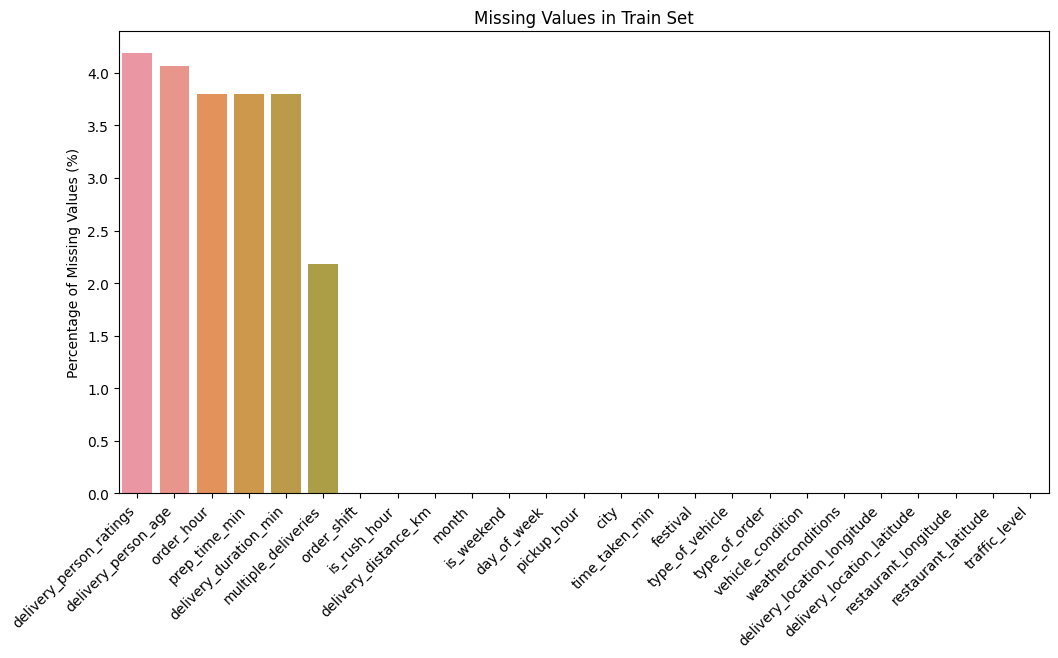

In [41]:
# Calculate missing values
missing = train_df.isnull().sum()
missing_percent = (missing / len(train_df)) * 100

# Combine into a DataFrame
missing_df = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percent": missing_percent
}).sort_values(by="Missing_Percent", ascending=False)

print("Columns with missing values:\n", missing_df[missing_df["Missing_Count"] > 0])

# Plot missing percentages
plt.figure(figsize=(12,6))
sns.barplot(x=missing_df.index, y=missing_df["Missing_Percent"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Percentage of Missing Values (%)")
plt.title("Missing Values in Train Set")
plt.show()

In [42]:
#Handling Missing Value
# 1. Check missing values
missing = train_df.isnull().sum()
missing_percent = (missing / len(train_df)) * 100
missing_df = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percent": missing_percent
}).sort_values(by="Missing_Percent", ascending=False)

print("Columns with missing values:\n", missing_df[missing_df["Missing_Count"] > 0])

# 2. Split columns by type
numeric_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = train_df.select_dtypes(include=["object", "bool"]).columns.tolist()


# 3. Fill numeric columns with median
for col in numeric_cols:
    if train_df[col].isnull().sum() > 0:
        median_val = train_df[col].median()
        train_df[col].fillna(median_val, inplace=True)
    

# 4. Fill categorical columns with mode
for col in categorical_cols:
    if train_df[col].isnull().sum() > 0:
        mode_val = train_df[col].mode()[0]
        train_df[col].fillna(mode_val, inplace=True)
        

print("\n Missing values treated successfully.")



Columns with missing values:
                          Missing_Count  Missing_Percent
delivery_person_ratings           1908         4.184853
delivery_person_age               1854         4.066414
order_hour                        1731         3.796635
prep_time_min                     1731         3.796635
delivery_duration_min             1731         3.796635
multiple_deliveries                993         2.177966

 Missing values treated successfully.


In [43]:
# Convert 'NaN' strings to proper np.nan
train_df.replace(["NaN", "nan", "NULL", "null", "None"], np.nan, inplace=True)



In [44]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   delivery_person_age          45593 non-null  float64
 1   delivery_person_ratings      45593 non-null  float64
 2   restaurant_latitude          45593 non-null  float64
 3   restaurant_longitude         45593 non-null  float64
 4   delivery_location_latitude   45593 non-null  float64
 5   delivery_location_longitude  45593 non-null  float64
 6   weatherconditions            44977 non-null  object 
 7   vehicle_condition            45593 non-null  int64  
 8   type_of_order                45593 non-null  object 
 9   type_of_vehicle              45593 non-null  object 
 10  multiple_deliveries          45593 non-null  float64
 11  festival                     45365 non-null  object 
 12  city                         44393 non-null  object 
 13  time_taken_min  

## Data cleaning Analaysis
### Getting the data ready wasn’t straightforward — the train and test sets had missing timestamps, weird "NaN" strings, and even some messy values that needed cleaning. On top of that, we engineered new features like delivery distance, rush hours, and order shifts so the model could better understand real delivery patterns. The biggest challenge was making sure both train and test sets ended up with the same clean structure before modeling.

In [45]:
# --- Save Processed Data ---
import os

# Create the directory if it doesn't exist
processed_data_dir = 'data/processed'
os.makedirs(processed_data_dir, exist_ok=True)

# Define file paths
train_processed_path = os.path.join(processed_data_dir, 'train_processed.csv')
# Assuming you have a test dataframe processed similarly, uncomment the next line
# test_processed_path = os.path.join(processed_data_dir, 'test_processed.csv')

# Save the DataFrame to CSV
# Use index=False to avoid saving the row index as a column
train_df.to_csv(train_processed_path, index=False)
print(f"Processed training data saved to: {train_processed_path}")

# If you have a test set:
# test_df.to_csv(test_processed_path, index=False)
# print(f"Processed test data saved to: {test_processed_path}")

Processed training data saved to: data/processed/train_processed.csv


# Exploratory Data Analysis(EDA)

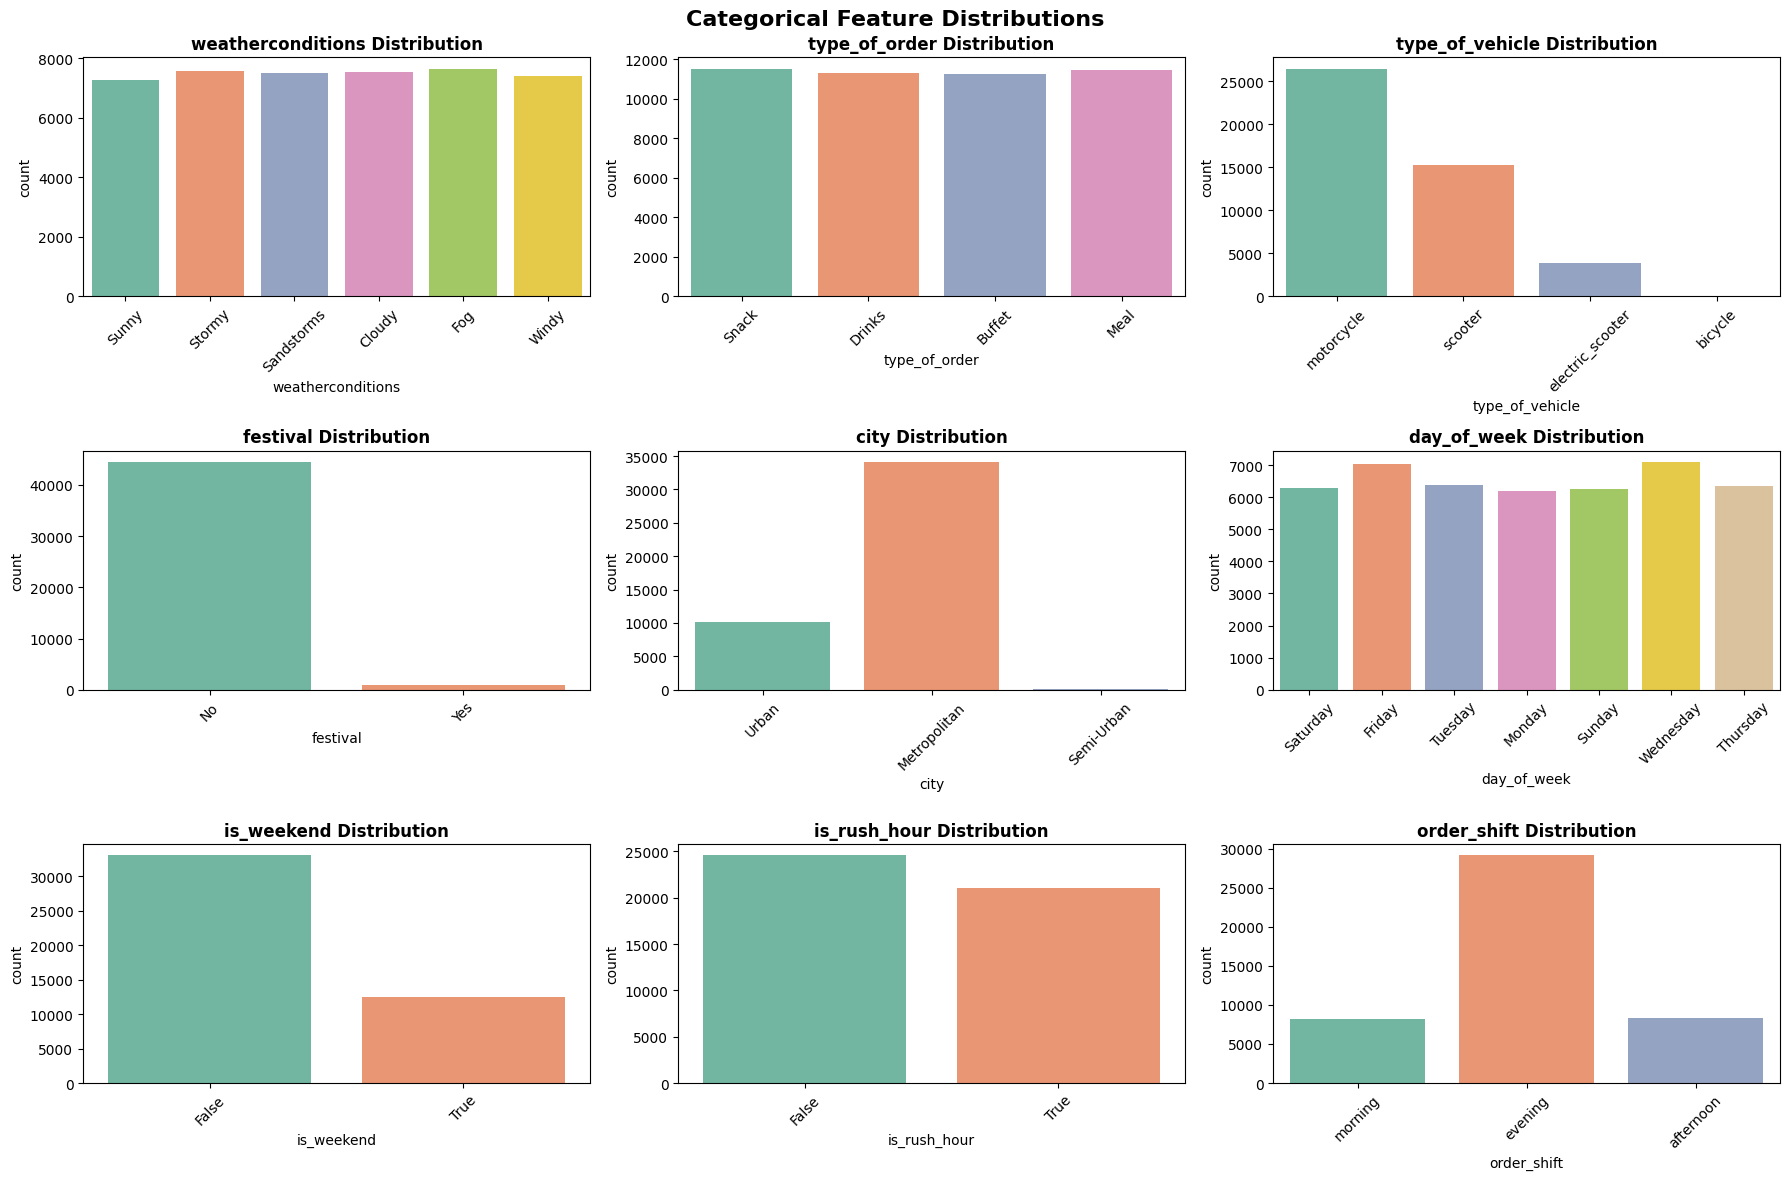

In [46]:
# Number of categorical columns
n_cols = len(categorical_cols)

# Rows and cols for subplots (arrange in grid)
n_rows = math.ceil(n_cols / 3)   # 3 plots per row
fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows * 4))

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot each categorical column
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=train_df, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} Distribution", fontsize=12, fontweight="bold")
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots (if any)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Categorical Feature Distributions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


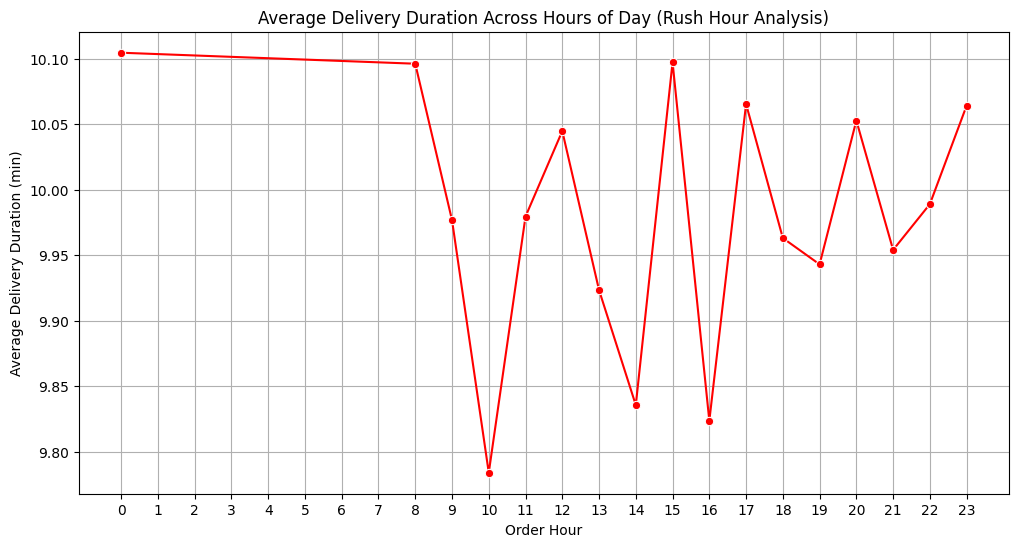

In [47]:
#Rush-hour
rush_df = train_df.groupby('order_hour')['delivery_duration_min'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=rush_df, x='order_hour', y='delivery_duration_min', marker='o', color='red')
plt.title("Average Delivery Duration Across Hours of Day (Rush Hour Analysis)")
plt.xlabel("Order Hour")
plt.ylabel("Average Delivery Duration (min)")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()


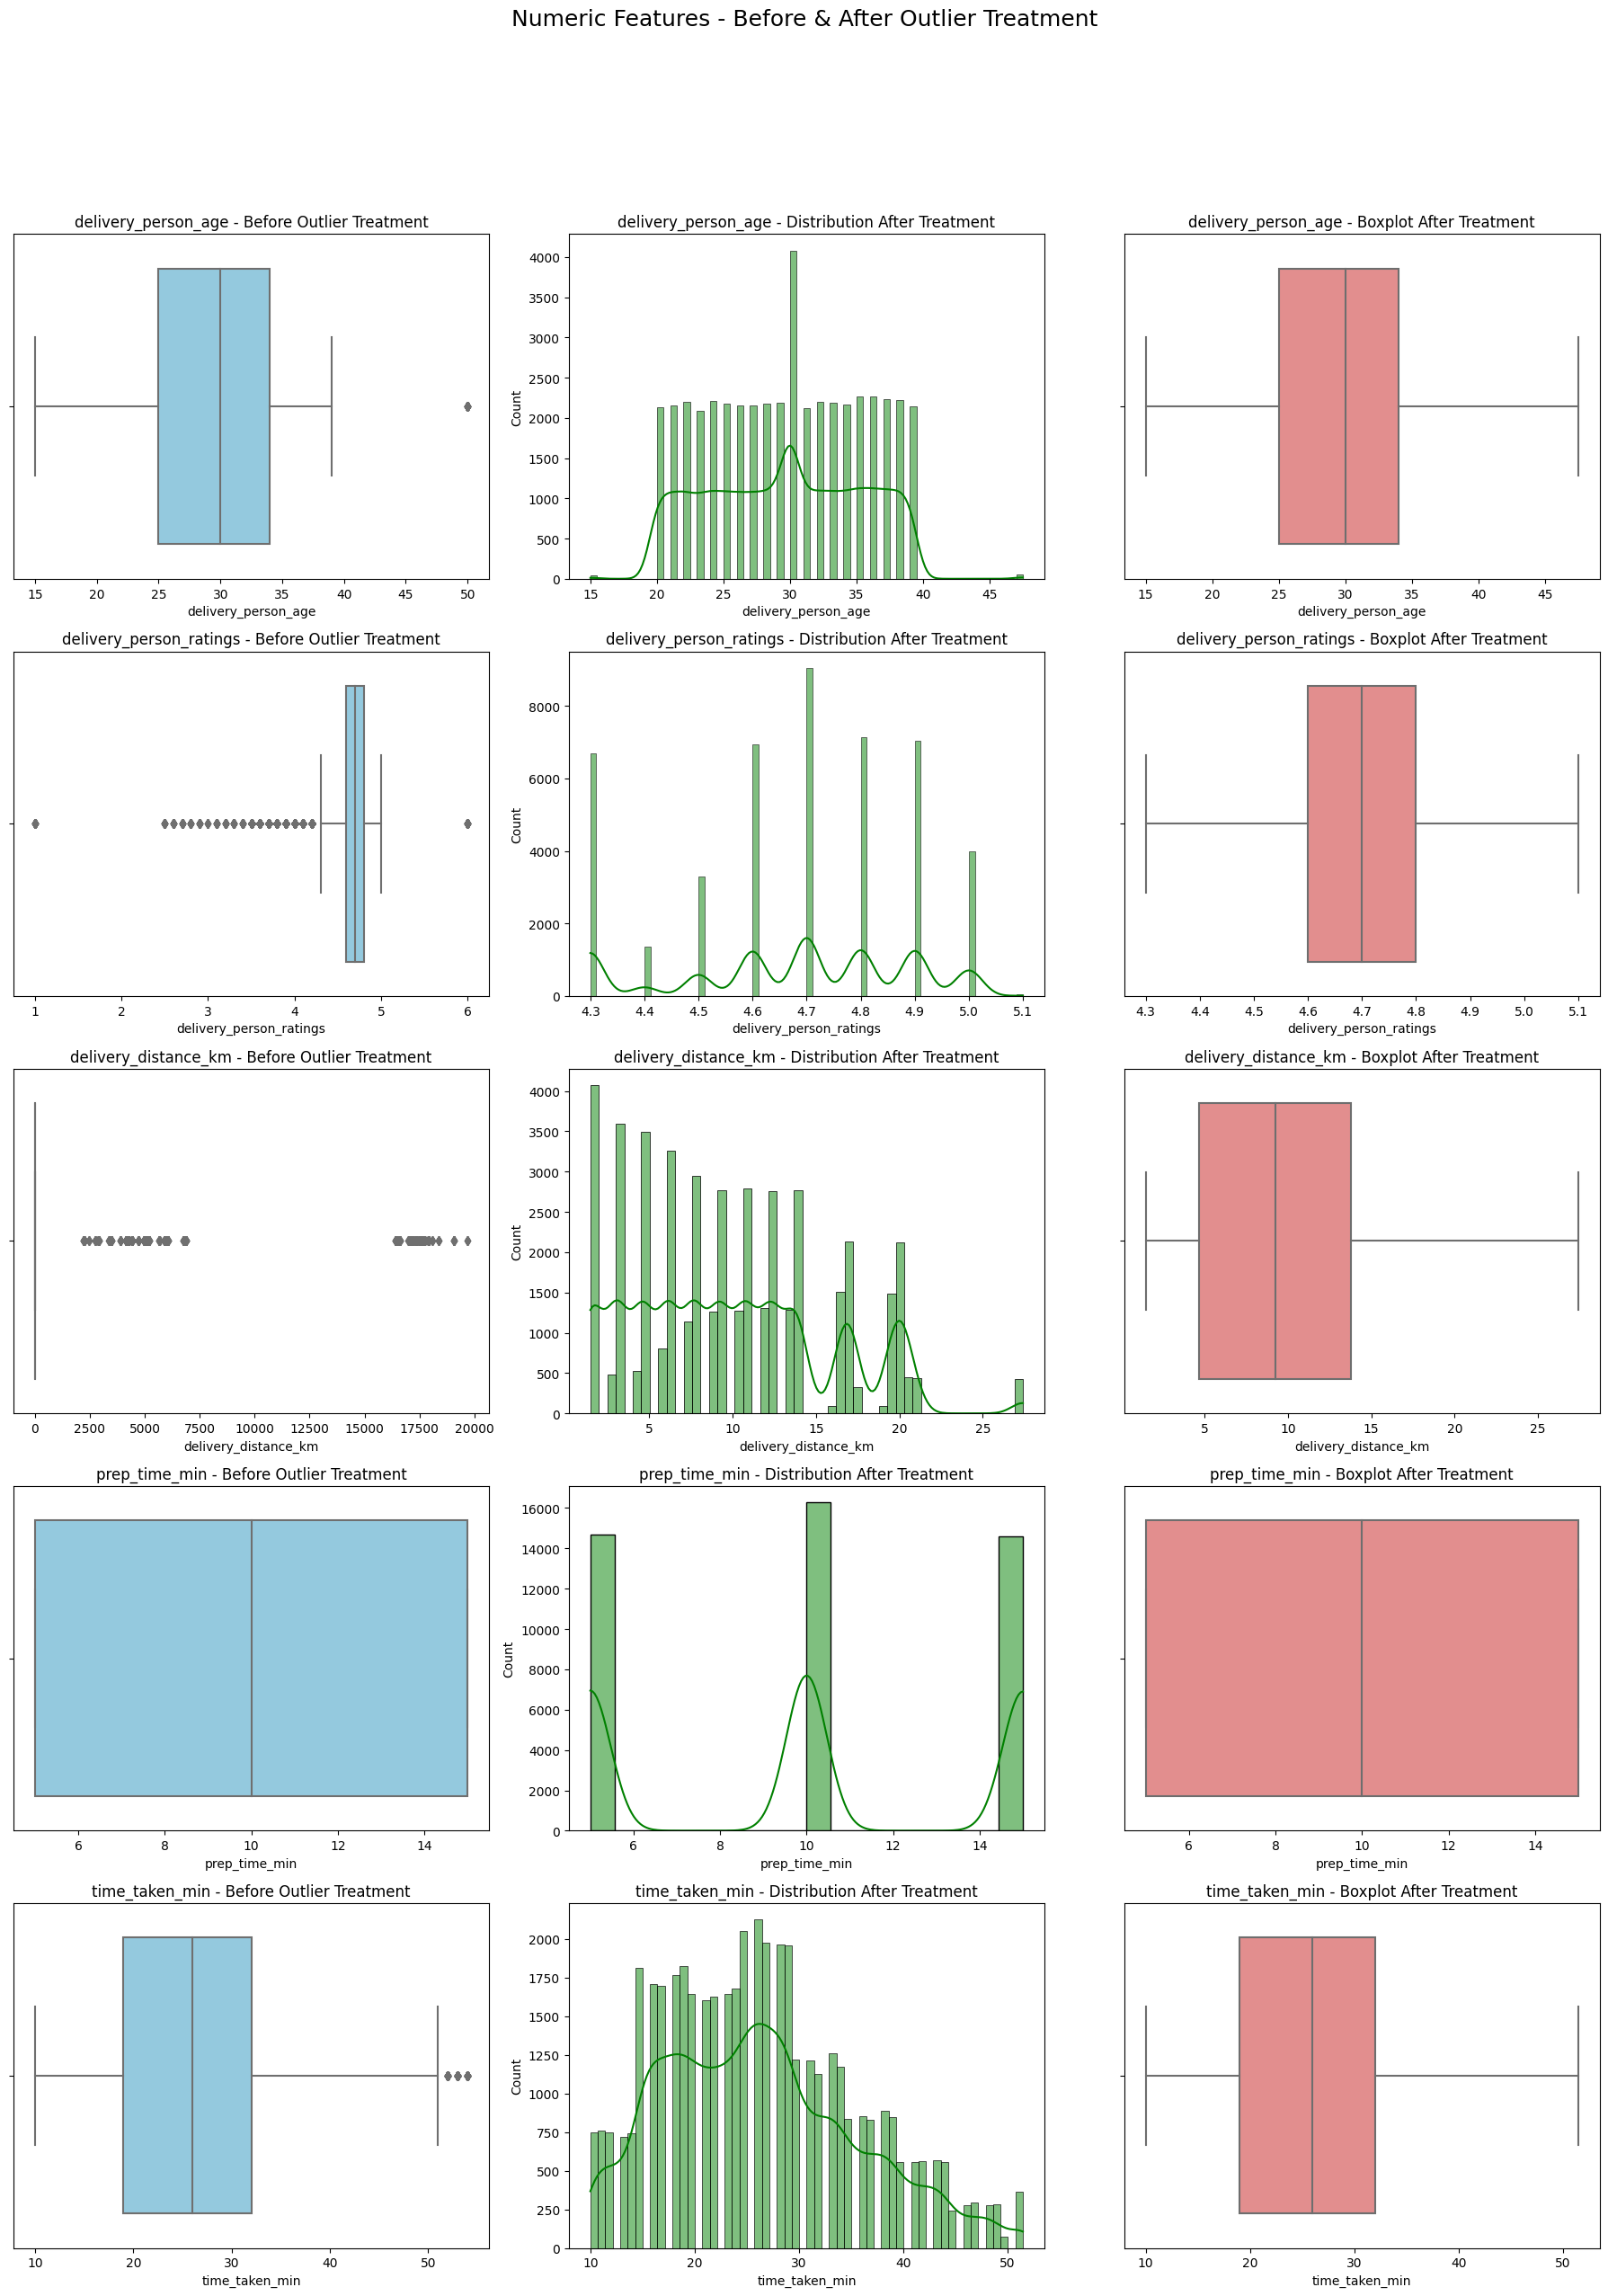

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Numeric columns to analyze
numeric_cols = ['delivery_person_age', 'delivery_person_ratings',
                'delivery_distance_km', 'prep_time_min', 'time_taken_min']

# Create figure
fig, axes = plt.subplots(len(numeric_cols), 3, figsize=(18, 5*len(numeric_cols)))
axes = np.array(axes)
if axes.ndim == 1:  # single row case
    axes = axes.reshape(len(numeric_cols), -1)

fig.suptitle("Numeric Features - Before & After Outlier Treatment", fontsize=18, y=1.02)

for i, col in enumerate(numeric_cols):
    # Before - boxplot
    sns.boxplot(x=train_df[col], ax=axes[i,0], color="skyblue")
    axes[i,0].set_title(f"{col} - Before Outlier Treatment")
    
    # IQR capping
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    # Cap in the actual DataFrame
    train_df[col] = np.where(train_df[col] > upper, upper,
                             np.where(train_df[col] < lower, lower, train_df[col]))
    
    # After - histogram
    sns.histplot(train_df[col], kde=True, ax=axes[i,1], color="green")
    axes[i,1].set_title(f"{col} - Distribution After Treatment")
    
    # After - boxplot
    sns.boxplot(x=train_df[col], ax=axes[i,2], color="lightcoral")
    axes[i,2].set_title(f"{col} - Boxplot After Treatment")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


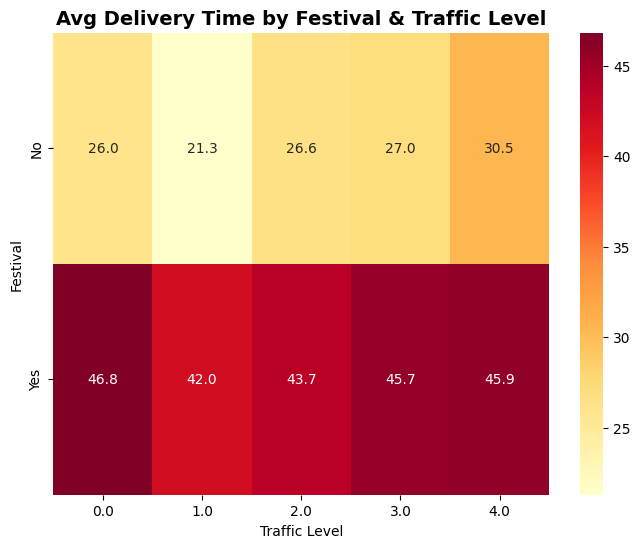

In [49]:
#Avg Delivery Time by Festival & Traffic Level
festival_traffic = train_df.groupby(["festival", "traffic_level"])["time_taken_min"].mean().unstack()
plt.figure(figsize=(8,6))
sns.heatmap(festival_traffic, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Avg Delivery Time by Festival & Traffic Level", fontsize=14, weight="bold")
plt.ylabel("Festival")
plt.xlabel("Traffic Level")
plt.show()


In [50]:
#Geospatial Folium Map
# Rough bounds for India
lat_min, lat_max = 6.0, 37.0
lon_min, lon_max = 68.0, 97.0

train_df = train_df[
    (train_df['restaurant_latitude'].between(lat_min, lat_max)) &
    (train_df['restaurant_longitude'].between(lon_min, lon_max)) &
    (train_df['delivery_location_latitude'].between(lat_min, lat_max)) &
    (train_df['delivery_location_longitude'].between(lon_min, lon_max))
]

sample = train_df.sample(200)

m = folium.Map(location=[sample['restaurant_latitude'].mean(),
                         sample['restaurant_longitude'].mean()],
               zoom_start=12)

for _, row in sample.iterrows():
    # Restaurant (red)
    folium.Marker(
        location=[row['restaurant_latitude'], row['restaurant_longitude']],
        icon=folium.Icon(color="red", icon="cutlery"),
        popup=f"Restaurant - City: {row['city']}"
    ).add_to(m)
    
    # Delivery location (blue)
    folium.Marker(
        location=[row['delivery_location_latitude'], row['delivery_location_longitude']],
        icon=folium.Icon(color="blue", icon="home"),
        popup=f"Delivery - {row['type_of_order']}"
    ).add_to(m)
    
    # Line between them
    folium.PolyLine(locations=[(row['restaurant_latitude'], row['restaurant_longitude']),
                               (row['delivery_location_latitude'], row['delivery_location_longitude'])],
                    color="gray", weight=1).add_to(m)

m


In [51]:
# Initialize map at the mean location
m = folium.Map(location=[train_df['restaurant_latitude'].mean(),
                         train_df['restaurant_longitude'].mean()],
               zoom_start=12)

# Sample first 100 deliveries for performance
sample = train_df.head(100)

for idx, row in sample.iterrows():
    # Coordinates
    start = [row['restaurant_latitude'], row['restaurant_longitude']]
    end = [row['delivery_location_latitude'], row['delivery_location_longitude']]
     # Restaurant (red)
    folium.Marker(
        location=[row['restaurant_latitude'], row['restaurant_longitude']],
        icon=folium.Icon(color="red", icon="cutlery"),
        popup=f"Restaurant - City: {row['city']}"
    ).add_to(m)
    
    # Delivery location (blue)
    folium.Marker(
        location=[row['delivery_location_latitude'], row['delivery_location_longitude']],
        icon=folium.Icon(color="blue", icon="home"),
        popup=f"Delivery - {row['type_of_order']}"
    ).add_to(m)

    # Distance (already calculated)
    distance_km = row['delivery_distance_km']
    
    # Draw line with tooltip showing distance
    folium.PolyLine(
        locations=[start, end],
        color='blue',
        weight=2,
        tooltip=f"{distance_km:.2f} km"
    ).add_to(m)
    
    
    folium.CircleMarker(location=start, radius=3, color='green', fill=True).add_to(m)
    folium.CircleMarker(location=end, radius=3, color='red', fill=True).add_to(m)

m


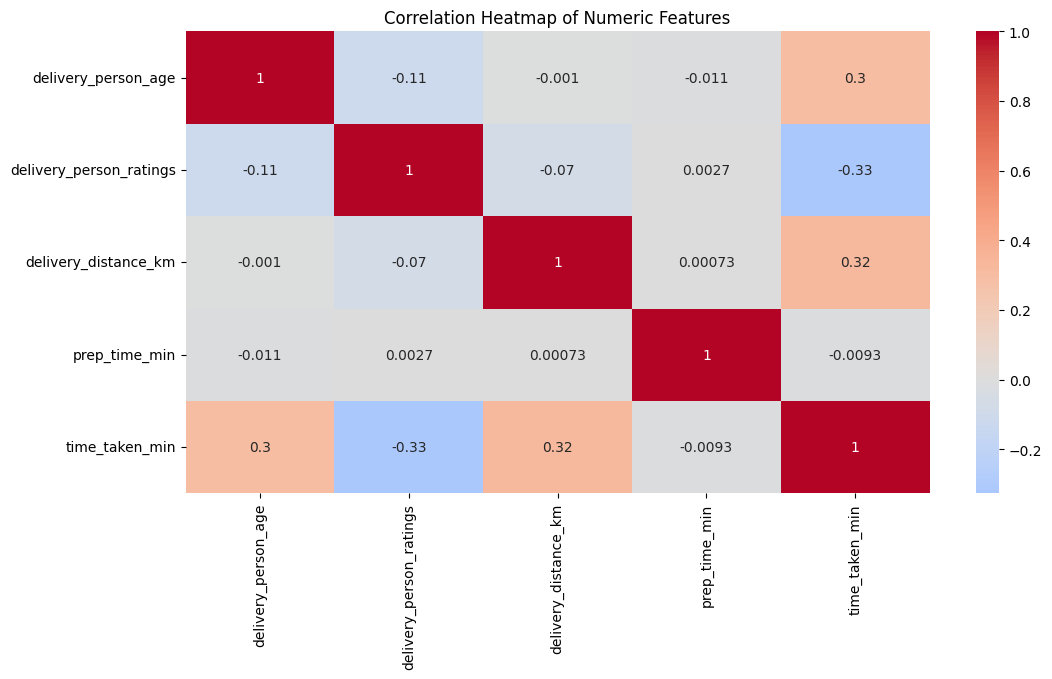

In [52]:
#Correlation Heatmap

plt.figure(figsize=(12,6))
corr = train_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## EDA Insight

### Before jumping into modeling, I wanted to really understand the data. I looked at missing values, how features like delivery person age, ratings, and distance were distributed, and even how traffic, weather, and festivals affected delivery times. Outliers were another challenge — some deliveries looked way too fast or way too slow to be real, so I checked their impact before and after cleaning. I also used maps (Folium) to see delivery routes, While plotting restaurant and delivery locations, I noticed a few points sitting out in the middle of the ocean . To fix this, I added rough geographic bounds, and broke down patterns by order hour and day of the week. This step gave me a clear picture of the key factors that drive delivery time.

In [53]:
train_df.columns

Index(['delivery_person_age', 'delivery_person_ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_location_latitude',
       'delivery_location_longitude', 'weatherconditions', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city', 'time_taken_min', 'order_hour', 'pickup_hour',
       'delivery_duration_min', 'day_of_week', 'is_weekend', 'month',
       'delivery_distance_km', 'prep_time_min', 'is_rush_hour', 'order_shift',
       'traffic_level'],
      dtype='object')

# Preprocessing Pipeline

In [54]:
#Define columns
numeric_features = ['delivery_person_age', 'delivery_person_ratings',
                    'delivery_distance_km', 'prep_time_min']

categorical_features = ['weatherconditions', 'type_of_order',
                        'type_of_vehicle', 'festival', 'city',
                        'day_of_week', 'is_weekend', 'is_rush_hour',
                        'order_shift', 'traffic_level']

target = "time_taken_min"


#Numeric Transformer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # Fill missing with median
    ('scaler', StandardScaler())                     # Scale features
])


# 3. Categorical Transformer
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Fill missing with mode
    ('encoder', OneHotEncoder(handle_unknown='ignore'))    # One-hot encode
])


#Combine with ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

#Build Preprocessing Pipeline

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])


# Features and target
X = train_df.drop(columns=[target])
y = train_df[target]

# Split into train and validation (e.g., 80% train, 20% val)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)



Training set: (33217, 24) (33217,)
Testing set: (8305, 24) (8305,)


## Preprocessing Insight

### I handled this step by using median/mode imputation, scaling numeric features, and one-hot encoding categories — all tied together in a pipeline so the process stayed consistent and clean.   



# Modelling

In [55]:
# Adding models
models = ({
    'RandomForest': RandomForestRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'LinearRegression': LinearRegression(),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0),
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1),
    'KNeighbors': KNeighborsRegressor(),
    'SVR': SVR()
})

## Adding Hyperparameters

In [56]:
# Hyperparameter grids for new models
param_grids = ({
    'RandomForest': {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [None, 10, 20],
        'regressor__min_samples_split': [2, 5],
    },
    'GradientBoosting': {
        'regressor__n_estimators': [100, 200],
        'regressor__learning_rate': [0.05, 0.1],
        'regressor__max_depth': [3, 5]
    },
    'LinearRegression':{},
    'XGBoost': {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [3, 6],
        'regressor__learning_rate': [0.05, 0.1]
    },
    'CatBoost': {
        'regressor__iterations': [200, 500],
        'regressor__depth': [4, 6],
        'regressor__learning_rate': [0.05, 0.1]
    },
    'LightGBM': {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [6, 10],
        'regressor__learning_rate': [0.05, 0.1]
    },
    'KNeighbors': {
        'regressor__n_neighbors': [3, 5, 7]
    },
    'SVR': {
        'regressor__C': [0.1, 1, 10],
        'regressor__gamma': ['scale', 'auto']
    }
})

## Finding the best model


In [57]:
# Finding the best model
best_models = {}
evaluation_results = {}

for name, model in models.items():
    print(f"Training and tuning: {name}")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])
    
    grid = GridSearchCV(pipeline, param_grids[name], cv=3, n_jobs=-1, scoring='r2')
    grid.fit(X_train, y_train)
    
    best_models[name] = grid.best_estimator_
    
    # Predict
    y_pred = best_models[name].predict(X_test)
    
    # Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    evaluation_results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}\n")

# Select best model
best_model_name = max(evaluation_results, key=lambda k: evaluation_results[k]['R2'])
best_model = best_models[best_model_name]
print(f"Best Model: {best_model_name}")

Training and tuning: RandomForest
RandomForest -> MAE: 3.62, RMSE: 4.62, R2: 0.76

Training and tuning: GradientBoosting
GradientBoosting -> MAE: 3.71, RMSE: 4.68, R2: 0.75

Training and tuning: LinearRegression
LinearRegression -> MAE: 5.14, RMSE: 6.53, R2: 0.52

Training and tuning: XGBoost
XGBoost -> MAE: 3.65, RMSE: 4.63, R2: 0.76

Training and tuning: CatBoost
CatBoost -> MAE: 3.65, RMSE: 4.62, R2: 0.76

Training and tuning: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.198124 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 369
[LightGBM] [Info] Number of data points in the train set: 22145, number of used features: 42
[LightGBM] [Info] Start training from score 26.283224
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

##  The best model is LightGBm

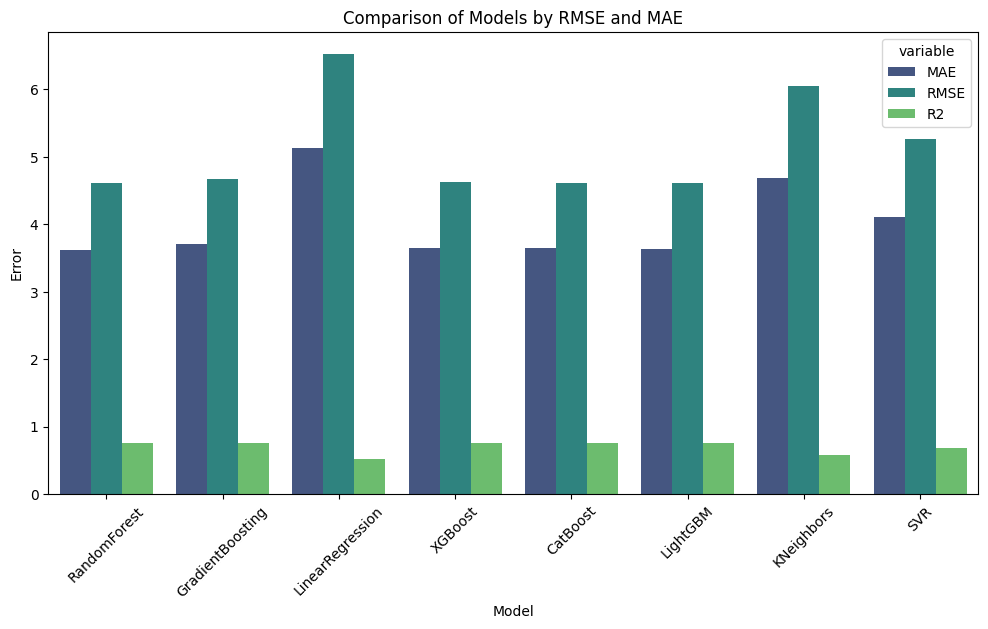

In [58]:
#plotting Comparison of Models by RMSE and MAE
# Convert to DataFrame
metrics_df = pd.DataFrame(evaluation_results).T.reset_index().rename(columns={'index':'Model'})

# Plot RMSE and MAE
plt.figure(figsize=(12,6))
sns.barplot(data=metrics_df.melt(id_vars='Model'), x='Model', y='value', hue='variable', palette='viridis')
plt.title('Comparison of Models by RMSE and MAE')
plt.ylabel('Error')
plt.xticks(rotation=45)
plt.show()

## Plot R2

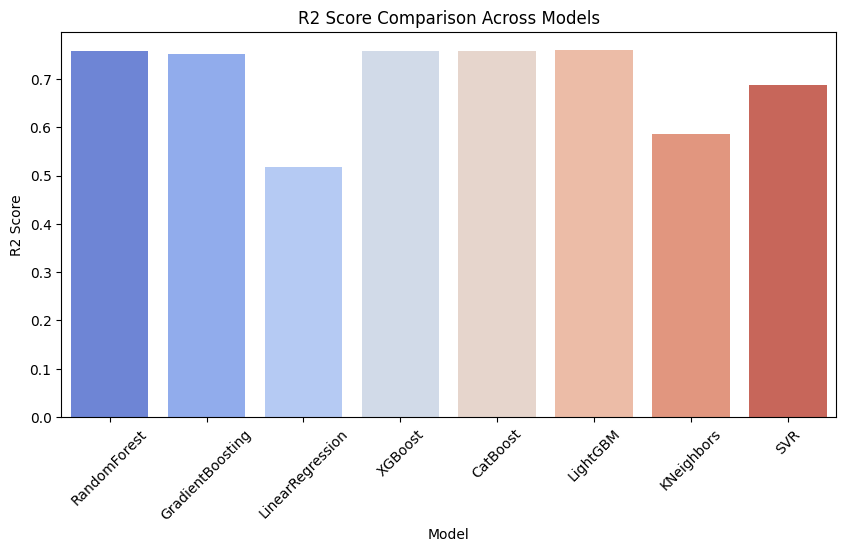

In [59]:
# Plot R2 
plt.figure(figsize=(10,5))
sns.barplot(data=metrics_df, x='Model', y='R2', palette='coolwarm')
plt.title('R2 Score Comparison Across Models')
plt.ylabel('R2 Score')
plt.xticks(rotation=45)
plt.show()

In [60]:
# --- Save Trained Model ---
import joblib
import pickle

# Create the directory for models if it doesn't exist
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# Define filenames
joblib_filename = os.path.join(models_dir, 'final_model.joblib')
pickle_filename = os.path.join(models_dir, 'final_model.pkl')

# Save using joblib (generally more efficient for large numpy arrays/sklearn models)
# 'best_model' should be the variable holding your trained pipeline or regressor
joblib.dump(best_model, joblib_filename)
print(f"Model saved using joblib at: {joblib_filename}")

# Save using pickle (standard Python serialization)
with open(pickle_filename, 'wb') as file:
    pickle.dump(best_model, file)
print(f"Model saved using pickle at: {pickle_filename}")

Model saved using joblib at: models/final_model.joblib
Model saved using pickle at: models/final_model.pkl


In [61]:
#Overview of feature importance
from sklearn.inspection import permutation_importance

feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
reg = best_model.named_steps['regressor']

# Use permutation importance instead of feature_importances_
X_test_prep = best_model.named_steps['preprocessor'].transform(X_test)
r = permutation_importance(reg, X_test_prep, y_test, n_repeats=10, random_state=42)

importances = r.importances_mean

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})
feat_imp[:7]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.228108 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 369
[LightGBM] [Info] Number of data points in the train set: 22144, number of used features: 42
[LightGBM] [Info] Start training from score 26.234104
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

,feature,importance
0,num__delivery_person_age,0.206579
1,num__delivery_person_ratings,0.257968
2,num__delivery_distance_km,0.316938
3,num__prep_time_min,0.000068
4,cat__weatherconditions_Cloudy,0.101082
5,cat__weatherconditions_Fog,0.104549
6,cat__weatherconditions_Sandstorms,0.002415


## Feature Importance  Plotting

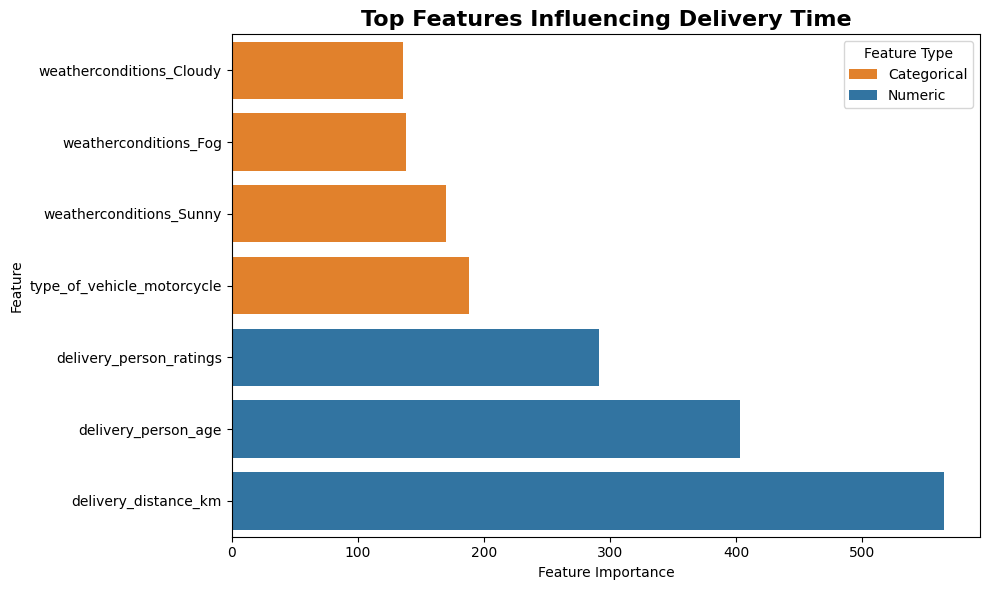

In [62]:
#Feature Importance  Plotting
feature_importances = pd.DataFrame({
    "feature": ['delivery_distance_km', 'delivery_person_age', 'delivery_person_ratings',
                'type_of_vehicle_motorcycle', 'weatherconditions_Sunny', 'weatherconditions_Fog',
                'weatherconditions_Cloudy'],
    "importance": [565, 403, 291, 188, 170, 138, 136]
})

# Identify numeric vs categorical
feature_importances["type"] = feature_importances["feature"].apply(
    lambda x: "Numeric" if x.startswith("num") or x in ['delivery_distance_km', 'delivery_person_age', 'delivery_person_ratings'] else "Categorical"
)

# Sort by importance
feature_importances = feature_importances.sort_values(by="importance", ascending=True)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=feature_importances, hue="type", dodge=False, palette={"Numeric":"#1f77b4","Categorical":"#ff7f0e"})
plt.title("Top Features Influencing Delivery Time", fontsize=16, fontweight="bold")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.legend(title="Feature Type")
plt.tight_layout()
plt.show()

## Modeling Overview  

### I tested several regression models to predict delivery time, including **Random Forest, XGBoost, CatBoost, and LightGBM**. After comparing their performance using **RMSE, MAE, and R² scores**, **LightGBM** emerged as the best model with the lowest errors and highest R².  

### To understand how the models performed, I plotted **R² scores** for all candidates — LightGBM clearly stood out. Finally, I examined **feature importances** from the trained LightGBM model, which showed that **delivery distance, delivery person age, ratings, vehicle type, and weather** were the most influential factors in predicting delivery time.  


# Quick Prediction Test

In [63]:
# Minimal scenario (real values for 4 features, dummies for rest)
scenario = pd.DataFrame([{
    'delivery_person_age': 25,
    'delivery_person_ratings': 4.7,
    'delivery_distance_km': 6.0,
    'prep_time_min': 12,

    # Dummy placeholders
    'restaurant_latitude': 12.97,
    'restaurant_longitude': 77.59,
    'delivery_location_latitude': 13.01,
    'delivery_location_longitude': 77.60,
    'weatherconditions': 'Sunny',
    'vehicle_condition': 1,
    'type_of_order': 'Snack',
    'type_of_vehicle': 'motorcycle',
    'multiple_deliveries': 1,
    'festival': 'No',
    'city': 'Metropolitan',
    'order_hour': 14,
    'pickup_hour': 14,
    'day_of_week': 'Monday',
    'is_weekend': False,
    'month': 9,
    'is_rush_hour': True,
    'order_shift': 'afternoon',
    'traffic_level': 2.0
}])

pred_time = best_model.predict(scenario)
print(f"Predicted delivery time: {pred_time[0]:.2f} minutes")


Predicted delivery time: 17.34 minutes


In [ ]:
import joblib
pipeline.fit(X_train, y_train)
joblib.dump(pipeline, "models/Downloadsdelivery_time_model.pkl") 

# Final Thoughts & Recommendation  

###  By carefully cleaning the data and building a robust pipeline, we were able to predict delivery times accurately. LightGBM turned out to be the best model, and key factors like distance, driver experience, vehicle type, and weather played the biggest roles.  

### I also tested a **minimal scenario** using real values for just 4 key features and dummy values for the rest, and created an interactive **dashboard using Streamlit** for quick predictions.  

### **Recommendation:** Focus on optimizing delivery routes, training delivery personnel, and monitoring weather conditions to reduce delivery times and improve customer satisfaction.  
